In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from package import *



import time


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import matplotlib.pyplot as plt


from IPython.display import clear_output, display

In [2]:

sliding_windows = 0.

context_window = 128
batch_size = 64

d_emb = 512
nb_heads = 4
d_k = d_emb // nb_heads

mlp_multiplication=3

nb_layers = 8

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#device = torch.device("cpu")
print(device)

mps


In [3]:

tokenizer = SingleCharTokenizer()
tokens = torch.tensor(tokenizer.load_tokens("../tokens_sc.tok"))
print(tokens.shape)


vocab_size = tokenizer.vocab_size
print("vocab_size : " , vocab_size)

dataset = TextDataset(tokens,context_window=context_window,sliding_windows=sliding_windows)
print("dataset_size : " ,len(dataset))


loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers = 2
)


torch.Size([11473626])
vocab_size :  65
dataset_size :  11473499


In [4]:


gpt = GPT(  vocab_size=vocab_size,
            context_window=context_window,
            d_emb=d_emb,
            nb_layers=nb_layers,
            nb_heads=nb_heads, 
            mlp_multiplication=mlp_multiplication
            ).to(device)
gpt.architecture()

PARAMETERS :
embedding.E.weight: mps:0 torch.Size([65, 512]) 33280
embedding.P.weight: mps:0 torch.Size([128, 512]) 65536
transformer_blocks.0.norm1.weight: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm1.bias: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm2.weight: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm2.bias: mps:0 torch.Size([512]) 512
transformer_blocks.0.attention.Wq.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wk.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wv.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wo.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.feed_forward.NN.0.weight: mps:0 torch.Size([1536, 512]) 786432
transformer_blocks.0.feed_forward.NN.0.bias: mps:0 torch.Size([1536]) 1536
transformer_blocks.0.feed_forward.NN.2.weight: mps:0 torch.Size([512, 1536]) 786432
transformer_blocks.0.feed_forward.NN.2.bias: mps:0 torch.Size([512]) 512
tr

In [5]:

engine = Engine(gpt,tokenizer,device)
print(len(iter(loader)))


179273


|----------------------------------------| 0/1 [27.2s<0.0s, 0.0 it/s]
|████████--------------------------------| 40/200 [27.2s<108.8s, 1.5 it/s]
Loss : 2.32027006149292

je pense que ctons elitis eueux le des, an 


KeyboardInterrupt: 

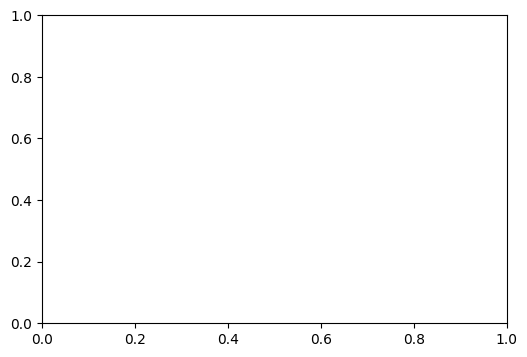

In [7]:

engine.train(loader,1,2000,200,print_frequency=10)

engine.save_model("training_historic/final.w")
engine.save("training_historic/final.e")